In [79]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import country_converter as coco
cc = coco.CountryConverter()
eu27 = cc.EU27as("ISO2").ISO2.tolist()

jrc_names = {"GR": "EL", "GB": "UK"}

ktoe_to_twh = 0.011630

In [80]:
path = Path.cwd().parent / 'results' / 'networks'
n = pypsa.Network(path / 'base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc')

INFO:pypsa.io:Imported network base_s_50_24H_24H-T-H-B-I-A-dist1_2025.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [5]:
sector_sheets = {
    "Integrated steelworks": "FC_IND_IS_BF_E",
    "Electric arc": "FC_IND_IS_EA_E",
    "Alumina production": "FC_IND_NFM_AM_E",
    "Aluminium - primary production": "FC_IND_NFM_PA_E",
    "Aluminium - secondary production": "FC_IND_NFM_SA_E",
    "Other non-ferrous metals": "FC_IND_NFM_OM_E",
    "Basic chemicals": "FC_IND_CPC_BC_E",
    "Other chemicals": "FC_IND_CPC_OC_E",
    "Pharmaceutical products etc.": "FC_IND_CPC_PH_E",
    "Basic chemicals feedstock": "FC_IND_CPC_NE",
    "Cement": "FC_IND_NMM_CM_E",
    "Ceramics & other NMM": "FC_IND_NMM_CR_E",
    "Glass production": "FC_IND_NMM_GL_E",
    "Pulp production": "FC_IND_PPP_PU_E",
    "Paper production": "FC_IND_PPP_PA_E",
    "Printing and media reproduction": "FC_IND_PPP_PR_E",
    "Food, beverages and tobacco": "FC_IND_FBT_E",
    "Transport equipment": "FC_IND_TE_E",
    "Machinery equipment": "FC_IND_MAC_E",
    "Textiles and leather": "FC_IND_TL_E",
    "Wood and wood products": "FC_IND_WP_E",
    "Mining and quarrying": "FC_IND_MQ_E",
    "Construction": "FC_IND_CON_E",
    "Non-specified": "FC_IND_NSP_E",
}

In [8]:
fuels = {
    "Total": "all",
    "Solid fossil fuels": "solid",
    "Peat and peat products": "solid",
    "Oil shale and oil sands": "solid",
    "Oil and petroleum products": "liquid",
    "Manufactured gases": "gas",
    "Natural gas": "gas",
    "Nuclear heat": "heat",
    "Heat": "heat",
    "Renewables and biofuels": "biomass",
    "Non-renewable waste": "waste",
    "Electricity": "electricity",
}

In [9]:
path = Path.cwd().parent / 'data' / 'jrc-idees-2021'

In [ ]:
def industrial_energy_demand_per_country(country, year, jrc_dir, endogenous_ammonia):
    jrc_country = jrc_names.get(country, country)
    fn = f"{jrc_dir}/{jrc_country}/JRC-IDEES-2021_EnergyBalance_{jrc_country}.xlsx"

    sheets = list(sector_sheets.values())
    df_dict = pd.read_excel(fn, sheet_name=sheets, index_col=0)

    def get_subsector_data(sheet):
        df = df_dict[sheet][year].groupby(fuels).sum()

        df["hydrogen"] = 0.0

        # ammonia is handled separately
        if endogenous_ammonia:
            df["ammonia"] = 0.0

        df["other"] = df["all"] - df.loc[df.index != "all"].sum()

        return df

    df = pd.concat(
        {sub: get_subsector_data(sheet) for sub, sheet in sector_sheets.items()}, axis=1
    )

    sel = ["Mining and quarrying", "Construction", "Non-specified"]
    df["Other industrial sectors"] = df[sel].sum(axis=1)
    df["Basic chemicals"] += df["Basic chemicals feedstock"]

    df.drop(columns=sel + ["Basic chemicals feedstock"], index="all", inplace=True)

    df *= ktoe_to_twh
    return df

In [40]:
from tqdm import tqdm

years = list(range(2000, 2022))
data = []

for year in tqdm(years):
    df = industrial_energy_demand_per_country("DE", year, path, False).loc['heat'].rename(year)
    data.append(df)

100%|██████████| 22/22 [00:20<00:00,  1.05it/s]


In [41]:
df.index

Index(['Integrated steelworks', 'Electric arc', 'Alumina production',
       'Aluminium - primary production', 'Aluminium - secondary production',
       'Other non-ferrous metals', 'Basic chemicals', 'Other chemicals',
       'Pharmaceutical products etc.', 'Cement', 'Ceramics & other NMM',
       'Glass production', 'Pulp production', 'Paper production',
       'Printing and media reproduction', 'Food, beverages and tobacco',
       'Transport equipment', 'Machinery equipment', 'Textiles and leather',
       'Wood and wood products', 'Other industrial sectors'],
      dtype='object')

In [37]:
df = pd.concat(data, axis=1)
df = df.loc[df.sum(axis=1) > 0.02 * df.sum().sum()]

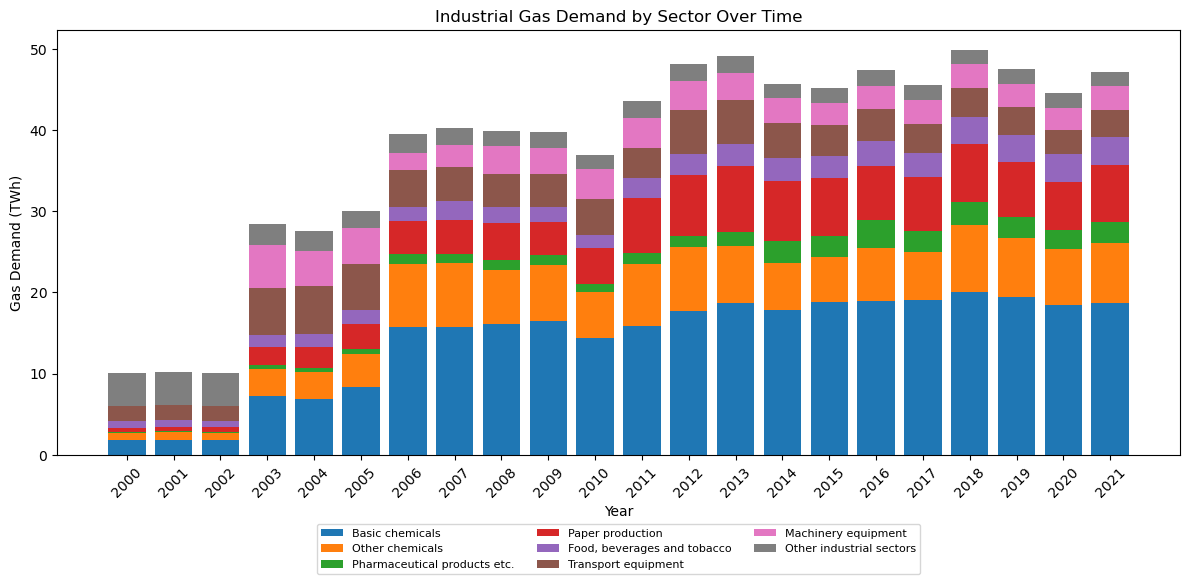

In [38]:
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

# Create bottom array to track stacking positions
bottom = np.zeros(len(df.columns))

# Plot each industrial sector as a stacked bar
for sector in df.index:
    axes.bar(range(len(df.columns)), df.loc[sector], bottom=bottom, label=sector, width=0.8)
    bottom += df.loc[sector].values

# Set x-axis labels to years
axes.set_xticks(range(len(df.columns)))
axes.set_xticklabels(df.columns, rotation=45)
axes.set_xlabel('Year')
axes.set_ylabel('Gas Demand (TWh)')
axes.set_title('Industrial Gas Demand by Sector Over Time')

# Create legend below the plot
axes.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)

plt.tight_layout()
plt.show()


3671.169113933888

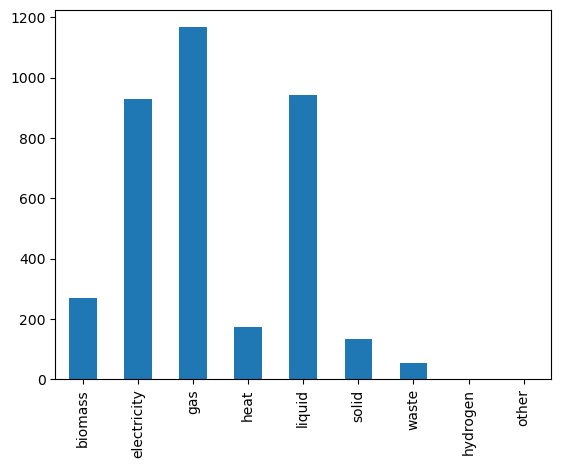

In [46]:
industrial_energy_demand_per_country("EU27", 2021, path, False).sum(axis=1).plot.bar(stacked=True)
industrial_energy_demand_per_country("EU27", 2021, path, False).sum(axis=1).sum()

In [47]:
eu = industrial_energy_demand_per_country("EU27", 2021, path, False)

In [48]:
eu

,Integrated steelworks,Electric arc,Alumina production,Aluminium - primary production,Aluminium - secondary production,Other non-ferrous metals,Basic chemicals,Other chemicals,Pharmaceutical products etc.,Cement,...,Glass production,Pulp production,Paper production,Printing and media reproduction,"Food, beverages and tobacco",Transport equipment,Machinery equipment,Textiles and leather,Wood and wood products,Other industrial sectors
biomass,0.350321,1.984523e-01,8.063393e-02,0.032897,7.806144e-03,0.109802,3.184940,1.719168e+00,6.609547e-01,1.136346e+01,...,2.013112e-01,69.332019,7.966846e+01,0.246705,15.987855,0.487531,1.799315e+00,3.687140e-01,61.657145,1.144776e+01
electricity,51.048151,5.405455e+01,5.121191e+00,26.652959,1.965010e+00,25.710670,109.507456,4.104946e+01,1.569886e+01,1.489269e+01,...,1.860201e+01,40.664016,4.274982e+01,16.690585,112.864337,45.540961,1.092801e+02,1.597361e+01,28.250078,1.204266e+02
gas,105.602010,2.970760e+01,1.662221e+01,2.932340,2.629014e+00,21.333174,307.524632,6.178372e+01,2.448110e+01,5.122259e+01,...,3.282268e+01,13.469846,7.088327e+01,3.458778,159.185281,26.037831,7.050335e+01,1.965864e+01,6.957570,6.509423e+01
heat,3.724818,1.201879e+00,3.131190e-01,0.057563,1.164819e-01,1.134817,56.686400,2.094954e+01,6.477219e+00,1.000911e+00,...,0.000000e+00,4.870626,2.173705e+01,0.000000,18.352898,6.682663,7.755470e+00,1.496229e+00,8.973598,9.081403e+00
liquid,3.524623,2.293501e+00,8.059915e-01,0.139196,2.012037e-01,2.283525,731.946167,1.774567e+01,3.756200e+00,2.836368e+01,...,2.246182e+00,2.510879,5.711413e+00,0.074180,16.566591,1.798641,9.760554e+00,1.701011e+00,2.271689,7.910311e+01
solid,29.104580,1.242483e+00,7.153739e-01,0.104393,3.208954e-02,1.281945,20.604275,1.017737e+01,1.024742e+00,1.755689e+01,...,7.595585e+00,2.101461,5.907323e+00,0.000000,12.550579,2.035030,8.122150e-01,1.685620e-01,0.409957,3.573749e+00
waste,0.019186,3.319483e-03,5.049518e-02,0.002224,2.882424e-03,0.014029,2.999721,1.223292e+00,5.364989e-01,2.599870e+01,...,0.000000e+00,0.437188,2.486138e+00,0.000000,0.092274,0.006129,1.286760e-01,4.498000e-03,0.323384,1.117561e+00
hydrogen,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
other,0.000000,1.057742e-14,-5.288712e-15,0.000000,6.610890e-16,0.000000,0.000000,-2.115485e-14,1.057742e-14,-2.115485e-14,...,-1.057742e-14,0.000000,4.230969e-14,0.000000,0.000000,0.000000,-4.230969e-14,5.288712e-15,0.000000,-1.586614e-14


In [72]:
demand = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industrial_energy_demand_base_s_50_2025.csv', index_col=0
)

In [74]:
demand = demand.loc[demand.sum(axis=1).sort_values(ascending=False).index]

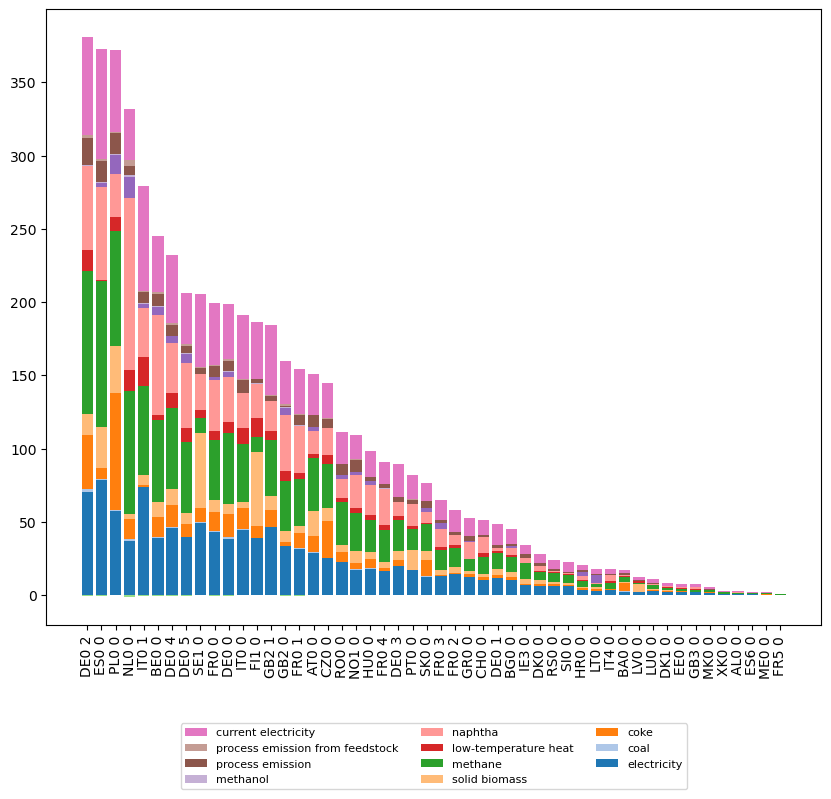

In [75]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, name in enumerate(demand.index):
    
    ss = demand.loc[name]

    pos = ss.loc[ss > 0]
    neg = ss.loc[ss < 0]

    bottom_pos = 0
    for col, val in pos.items():
        ax.bar(i, val, bottom=bottom_pos, label=col if i == 0 else "", color=plt.cm.tab20(demand.columns.get_loc(col)))
        bottom_pos += val
    
    bottom_neg = 0
    for col, val in neg.items():
        ax.bar(i, val, bottom=bottom_neg, color=plt.cm.tab20(demand.columns.get_loc(col)))
        bottom_neg += val

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)

ax.set_xticks(range(len(demand.index)))
ax.set_xticklabels(demand.index, rotation=90)

plt.show()

In [76]:
d = demand.sum(axis=1).div(demand.sum(axis=1).sum()).round(4) * 100
d.index.name = '%'
d.groupby(d.index.str[:2]).sum().sort_values(ascending=False).head()

%
DE    21.31
FR    10.47
IT     9.01
ES     6.93
PL     6.87
dtype: float64

In [77]:
d = demand.T.sum(axis=1).div(demand.sum(axis=1).sum()).round(4) * 100
d.sort_values()

hydrogen                           -0.16
methanol                            0.16
coal                                0.26
process emission from feedstock     0.42
ammonia                             1.61
low-temperature heat                3.43
process emission                    3.52
coke                                6.56
solid biomass                       6.79
naphtha                            16.56
current electricity                19.33
electricity                        19.79
methane                            21.72
dtype: float64

In [95]:
b = n.buses.index[n.buses.carrier == 'NH3']

In [98]:
n.loads.carrier.unique()

array(['electricity', 'land transport EV', 'land transport oil',
       'urban central heat', 'solid biomass for industry',
       'gas for industry', 'H2 for industry', 'industry methanol',
       'naphtha for industry', 'low-temperature heat for industry',
       'industry electricity', 'process emissions', 'NH3',
       'coal for industry', 'shipping oil', 'kerosene for aviation',
       'agriculture electricity', 'agriculture heat',
       'agriculture machinery electric', 'agriculture machinery oil',
       'rural heat', 'urban decentral heat'], dtype=object)

In [102]:
df = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industrial_production_per_country.csv',
    index_col=0
)

In [103]:
df.columns

Index(['Electric arc', 'Integrated steelworks', 'Other chemicals',
       'Pharmaceutical products etc.', 'Cement', 'Ceramics & other NMM',
       'Glass production', 'Pulp production', 'Paper production',
       'Printing and media reproduction', 'Food, beverages and tobacco',
       'Alumina production', 'Aluminium - primary production',
       'Aluminium - secondary production', 'Other non-ferrous metals',
       'Transport equipment', 'Machinery equipment', 'Textiles and leather',
       'Wood and wood products', 'Other industrial sectors', 'Ammonia', 'HVC',
       'Chlorine', 'Methanol'],
      dtype='object')

In [111]:
ratios = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industry_sector_ratios.csv', index_col=0
)

In [114]:
demand = pd.read_csv(
    Path.cwd().parent / 'resources' / 'industrial_energy_demand_per_country_today.csv',
    header=[0, 1],
    index_col=0,
)

# in Mt/a
production = (
    pd.read_csv(
        Path.cwd().parent / 'resources' / 'industrial_production_per_country.csv',
        index_col=0,
        )
    / 1e3
).stack()
production.index.names = [None, None]

In [164]:
# -*- coding: utf-8 -*-
import pandas as pd

# Helper: convert specific heat demand from GJ per tonne to TWh per kilotonne
def gj_per_tonne_to_twh_per_kt(gj_per_t):
    # 1 GJ = 1e9 J; 1 TWh = 3.6e12 J -> 1 GJ = 2.777...e-7 TWh
    return gj_per_t / 3600.0

# Define products with (thermal) specific heat demand [GJ/t] and band shares
# Shares are for thermal heat only (electricity is not counted here).
specs = {
    # Steel
    "Electric arc":                 {"gj_per_t": 0.5,  "<100": 0.00, "100-200": 1.00, "200-500": 0.00, ">500": 0.00},
    "Integrated steelworks":        {"gj_per_t": 20.0, "<100": 0.00, "100-200": 0.00, "200-500": 0.00, ">500": 1.00},

    # Chemicals / refining adjacents
    "Other chemicals":              {"gj_per_t": 3.0,  "<100": 0.20, "100-200": 0.50, "200-500": 0.20, ">500": 0.10},
    "Pharmaceutical products etc.": {"gj_per_t": 2.0,  "<100": 0.50, "100-200": 0.50, "200-500": 0.00, ">500": 0.00},
    "Ammonia":                      {"gj_per_t": 28.0, "<100": 0.00, "100-200": 0.00, "200-500": 0.30, ">500": 0.70},
    "HVC":                          {"gj_per_t": 13.0, "<100": 0.00, "100-200": 0.10, "200-500": 0.20, ">500": 0.70},
    "Chlorine":                     {"gj_per_t": 1.0,  "<100": 0.00, "100-200": 1.00, "200-500": 0.00, ">500": 0.00},
    "Methanol":                     {"gj_per_t": 30.0, "<100": 0.00, "100-200": 0.00, "200-500": 0.30, ">500": 0.70},

    # Non-metallic minerals
    "Cement":                       {"gj_per_t": 2.4,  "<100": 0.00, "100-200": 0.00, "200-500": 0.00, ">500": 1.00},
    "Ceramics & other NMM":         {"gj_per_t": 3.0,  "<100": 0.00, "100-200": 0.30, "200-500": 0.00, ">500": 0.70},
    "Glass production":             {"gj_per_t": 9.0,  "<100": 0.00, "100-200": 0.10, "200-500": 0.00, ">500": 0.90},

    # Pulp & paper
    "Pulp production":              {"gj_per_t": 12.0, "<100": 0.20, "100-200": 0.80, "200-500": 0.00, ">500": 0.00},
    "Paper production":             {"gj_per_t": 11.5, "<100": 0.30, "100-200": 0.70, "200-500": 0.00, ">500": 0.00},
    "Printing and media reproduction":{"gj_per_t": 2.0,"<100": 0.50, "100-200": 0.50, "200-500": 0.00, ">500": 0.00},

    # Food/wood/textiles/other industry
    "Food, beverages and tobacco":  {"gj_per_t": 5.0,  "<100": 0.30, "100-200": 0.70, "200-500": 0.00, ">500": 0.00},
    "Textiles and leather":         {"gj_per_t": 8.0,  "<100": 0.20, "100-200": 0.80, "200-500": 0.00, ">500": 0.00},
    "Wood and wood products":       {"gj_per_t": 3.0,  "<100": 0.20, "100-200": 0.80, "200-500": 0.00, ">500": 0.00},
    "Other industrial sectors":     {"gj_per_t": 2.0,  "<100": 0.50, "100-200": 0.50, "200-500": 0.00, ">500": 0.00},
    "Transport equipment":          {"gj_per_t": 1.0,  "<100": 0.68, "100-200": 0.32, "200-500": 0.00, ">500": 0.00},
    "Machinery equipment":          {"gj_per_t": 1.0,  "<100": 0.68, "100-200": 0.32, "200-500": 0.00, ">500": 0.00},

    # Aluminium & alumina
    "Alumina production":           {"gj_per_t": 12.0, "<100": 0.00, "100-200": 0.65, "200-500": 0.00, ">500": 0.35},
    "Aluminium - primary production":{"gj_per_t": 2.4, "<100": 0.00, "100-200": 0.00, "200-500": 0.00, ">500": 1.00},
    "Aluminium - secondary production":{"gj_per_t": 1.0,"<100": 0.00, "100-200": 0.00, "200-500": 0.00, ">500": 1.00},

    # Non-ferrous (other)
    "Other non-ferrous metals":     {"gj_per_t": 5.0,  "<100": 0.00, "100-200": 0.50, "200-500": 0.00, ">500": 0.50},
}

# Build rows with computed TWh/kt per band
rows = []
bands = ["<100", "100-200", "200-500", ">500"]

for product, s in specs.items():
    gj_per_t = s["gj_per_t"]
    twh_per_kt_total = gj_per_t / 3600.0
    # compute each band
    band_values = {b: twh_per_kt_total * s[b] for b in bands}
    # sanity: shares sum to 1.0 (within tolerance)
    share_sum = sum(s[b] for b in bands)
    if abs(share_sum - 1.0) > 1e-9:
        raise ValueError(f"Shares for '{product}' sum to {share_sum:.3f}, not 1.0")
    rows.append({
        "product": product,
        "GJ_per_t": gj_per_t,
        "TWh_per_kt_total": twh_per_kt_total,
        **band_values
    })

df_heat_bands = pd.DataFrame(rows).sort_values("product").reset_index(drop=True)

# Show the DataFrame
df_heat_bands.set_index('product')


,GJ_per_t,TWh_per_kt_total,<100,100-200,200-500,>500
product,,,,,,
Alumina production,12.0,0.003333,0.000000,0.002167,0.000000,0.001167
Aluminium - primary production,2.4,0.000667,0.000000,0.000000,0.000000,0.000667
Aluminium - secondary production,1.0,0.000278,0.000000,0.000000,0.000000,0.000278
Ammonia,28.0,0.007778,0.000000,0.000000,0.002333,0.005444
Cement,2.4,0.000667,0.000000,0.000000,0.000000,0.000667
Ceramics & other NMM,3.0,0.000833,0.000000,0.000250,0.000000,0.000583
Chlorine,1.0,0.000278,0.000000,0.000278,0.000000,0.000000
Electric arc,0.5,0.000139,0.000000,0.000139,0.000000,0.000000
"Food, beverages and tobacco",5.0,0.001389,0.000417,0.000972,0.000000,0.000000


In [162]:
eu_prod = production.groupby(level=1).sum()

In [192]:
cols = ['<100', '100-200', '200-500', '>500']
df = pd.DataFrame(index=production.index.get_level_values(0).unique(), columns=cols)

for c in production.index.get_level_values(0).unique():
    ss = production.loc[c]
    df.loc[c] = df_heat_bands.set_index('product')[cols].mul(ss, axis=0).sum()

ss = production.groupby(level=1).sum()
df.loc['EU'] = df_heat_bands.set_index('product')[cols].mul(ss, axis=0).sum()

df = df.div(df.sum(axis=1), axis=0)

/tmp/ipykernel_1050653/634126578.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])


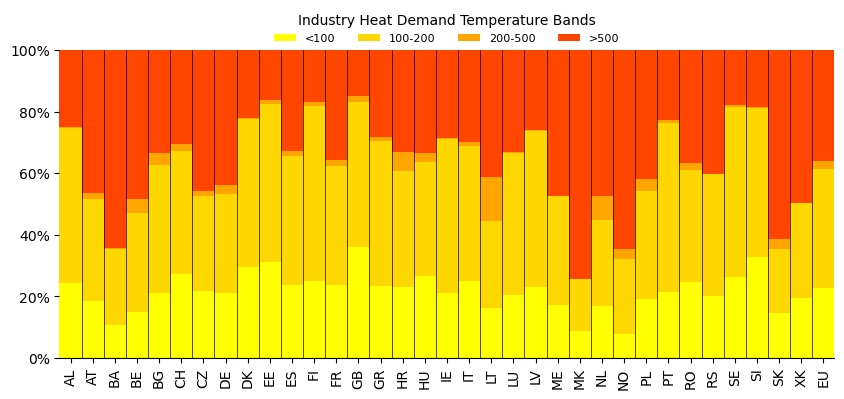

In [194]:
fig, ax = plt.subplots(figsize=(10, 4))


colors = ['#FFFF00', '#FFD700', '#FFA500', '#FF4500']  # yellow to red
bottom = np.zeros(len(df.index))

for i, band in enumerate(cols):
    ax.bar(range(len(df.index)), df[band].astype(float), bottom=bottom, color=colors[i], label=band, width=1)
    bottom += df[band].astype(float).values

ax.set_xticks(range(len(df.index)))
ax.set_xticklabels(df.index, rotation=90)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    fontsize=8,
    title='Industry Heat Demand Temperature Bands',
    frameon=False
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_ylim(0, 1)
ax.set_xlim(-0.5, len(df.index) - 0.5)

ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])

for val in range(1, len(df.index)+1):
    ax.axvline(val-0.5, color='black', linewidth=0.5)

plt.show()

In [118]:
idx = pd.IndexSlice

demand.loc[:,idx['DE',:]].round(2)

DE                                 \
            Alumina production Aluminium - primary production   
TWh/a                                                           
ammonia                   0.00                           0.00   
biomass                   0.00                           0.00   
electricity               1.65                           6.63   
gas                       3.92                           0.47   
heat                      0.23                           0.01   
hydrogen                  0.00                           0.00   
liquid                    0.21                           0.02   
other                     0.00                          -0.00   
solid                     0.13                           0.01   
waste                     0.05                           0.00   

                                                             \
            Aluminium - secondary production Ammonia Cement   
TWh/a                                                         
ammonia                                 0.00   15.15   0.00   
biomass                                 0.00    0.00   3.15   
electricity                             0.67    0.00   2.47   
gas                                     0.63    0.00   9.77   
heat                                    0.02    0.00   0.13   
hydrogen                                0.00    0.00   0.00   
liquid                                  0.03    0.00   2.05   
other                                  -0.00    0.00  -0.00   
solid                                   0.01    0.00   5.03   
waste                                   0.00    0.00   5.49   

                                                        \
            Ceramics & other NMM Chlorine Electric arc   
TWh/a                                                    
ammonia                     0.00     0.00         0.00   
biomass                     2.99     0.00         0.00   
electricity                 6.29     9.98         8.67   
gas                        13.74     0.00         5.14   
heat                        0.12     0.00         0.06   
hydrogen                    0.00    -2.60         0.00   
liquid                      2.19     0.00         0.03   
other                      -0.00     0.00         0.00   
solid                       7.02     0.00         0.44   
waste                       5.19     0.00         0.00   

                                                          ...                  \
            Food, beverages and tobacco Glass production  ... Other chemicals   
TWh/a                                                     ...                   
ammonia                            0.00             0.00  ...            0.00   
biomass                            0.85             0.02  ...            0.20   
electricity                       18.68             3.74  ...           10.62   
gas                               32.39             5.68  ...           14.04   
heat                               3.32             0.00  ...            7.22   
hydrogen                           0.00             0.00  ...            0.00   
liquid                             1.90             0.33  ...            2.42   
other                              0.00             0.00  ...           -0.00   
solid                              2.18             2.91  ...            0.98   
waste                              0.00             0.00  ...            0.53   

                                                               \
            Other industrial sectors Other non-ferrous metals   
TWh/a                                                           
ammonia                         0.00                     0.00   
biomass                         1.98                     0.00   
electricity                    23.54                     6.32   
gas                            16.69                     4.84   
heat                            1.88                     0.06   
hydrogen                        0

In [119]:
demand.div(production, axis=1).replace([np.inf, -np.inf], 0)

AL                                 \
            Alumina production Aluminium - primary production   
TWh/a                                                           
ammonia                    NaN                            NaN   
biomass                    NaN                            NaN   
electricity                NaN                            NaN   
gas                        NaN                            NaN   
heat                       NaN                            NaN   
hydrogen                   NaN                            NaN   
liquid                     NaN                            NaN   
other                      NaN                            NaN   
solid                      NaN                            NaN   
waste                      NaN                            NaN   

                                                                    \
            Aluminium - secondary production Ammonia        Cement   
TWh/a                                                                
ammonia                                  NaN     NaN  0.000000e+00   
biomass                                  NaN     NaN  5.751522e-02   
electricity                              NaN     NaN  8.497754e-02   
gas                                      NaN     NaN  2.876448e-01   
heat                                     NaN     NaN  6.469417e-03   
hydrogen                                 NaN     NaN  0.000000e+00   
liquid                                   NaN     NaN  1.847509e-01   
other                                    NaN     NaN -3.786685e-17   
solid                                    NaN     NaN  9.841100e-02   
waste                                    NaN     NaN  1.447650e-01   

                                                         \
            Ceramics & other NMM Chlorine  Electric arc   
TWh/a                                                     
ammonia             0.000000e+00   0.0000  0.000000e+00   
biomass             3.124925e-02   0.0000  2.402306e-03   
electricity         9.672927e-02   3.6000  8.354280e-01   
gas                 2.158383e-01   0.0000  4.460827e-01   
heat                6.814769e-03   0.0000  2.975918e-02   
hydrogen            0.000000e+00  -0.9372  0.000000e+00   
liquid              9.308872e-02   0.0000  2.885082e-02   
other              -1.059147e-17   0.0000 -3.748739e-17   
solid               5.713671e-02   0.0000  1.935553e-02   
waste               6.053111e-02   0.0000  7.341563e-05   

                                                          ...              XK  \
            Food, beverages and tobacco Glass production  ... Other chemicals   
TWh/a                                                     ...                   
ammonia                    0.000000e+00     0.000000e+00  ...    0.000000e+00   
biomass                    6.875985e-02     5.575311e-03  ...    4.901226e-02   
electricity                4.660608e-01     5.407539e-01  ...    1.442725e+00   
gas                        6.156276e-01     9.514082e-01  ...    1.974960e+00   
heat                       6.918059e-02     0.000000e+00  ...    7.484377e-01   
hydrogen                   0.000000e+00     0.000000e+00  ...    0.000000e+00   
liquid                     6.983526e-02     6.902069e-02  ...    6.442399e-01   
other                      5.648126e-17    -1.399701e-17  ...   -3.265624e-16   
solid                      5.555342e-02     2.454396e-01  ...    3.974142e-01   
waste                      3.570192e-04     0.000000e+00  ...    4.402402e-02   

                                                               \
            Other industrial sectors Other non-ferrous metals   
TWh/a                                                           
ammonia                 0.000000e+00                      NaN   
biomass                 1.306390e-02                      NaN   
electricity             1.368828e-01                      NaN   
gas                     6.440480e-02                      N

In [145]:
steel = pd.read_excel(
    Path.cwd().parent / 'data' / 'jrc-idees-2021' / 'DE' / 'JRC-IDEES-2021_EnergyBalance_DE.xlsx',
    sheet_name='FC_IND_IS_BF_E', index_col=0,
    # sheet_name='FC_IND_IS_EA_E', index_col=0,
)

In [146]:
steel[2021].loc[steel[2021] > 0]

Iron & steel - Integrated steelworks
Total                                                 5622.890069
Solid fossil fuels                                     636.278867
Hard coal                                              486.337314
Anthracite                                             433.387983
Other bituminous coal                                   52.949331
Coal products                                          149.941553
Brown coal briquettes                                  149.941553
Manufactured gases                                    1936.160181
Coke oven gas                                          555.748509
Blast furnace gas                                     1202.530247
Other recovered gases                                  177.881425
Oil and petroleum products                              49.667670
Oil products (excluding biofuel portion)                49.667670
Liquefied petroleum gases                                0.788367
Gas oil and diesel oil (excluding biofu

In [147]:
np.array(steel[2021].index)

array(['Total', 'Solid fossil fuels', 'Hard coal', 'Anthracite',
       'Coking coal', 'Other bituminous coal', 'Brown coal',
       'Sub-bituminous coal', 'Lignite', 'Coal products', 'Patent fuel',
       'Coke oven coke', 'Gas coke', 'Coal tar', 'Brown coal briquettes',
       'Manufactured gases', 'Gas works gas', 'Coke oven gas',
       'Blast furnace gas', 'Other recovered gases',
       'Peat and peat products', 'Peat', 'Peat products',
       'Oil shale and oil sands', 'Oil and petroleum products',
       'Crude oil, NGL, refinery feedstocks, additives and oxygenates and other hydrocarbons (excluding biofuel portion)',
       'Crude oil', 'Natural gas liquids', 'Refinery feedstocks',
       'Additives and oxygenates (excluding biofuel portion)',
       'Other hydrocarbons', 'Oil products (excluding biofuel portion)',
       'Refinery gas', 'Ethane', 'Liquefied petroleum gases',
       'Motor gasoline (excluding biofuel portion)', 'Aviation gasoline',
       'Gasoline-type jet fu

In [ ]:
steel = steel[2021].groupby(fuels).sum().sort_values()
steel["other"] = steel["all"] - steel.loc[steel.index != "all"].sum()

In [140]:
fuels = {
    "Total": "all",
    "Solid fossil fuels": "solid",
    "Peat and peat products": "solid",
    "Oil shale and oil sands": "solid",
    "Oil and petroleum products": "liquid",
    "Manufactured gases": "gas",
    "Natural gas": "gas",
    "Nuclear heat": "heat",
    "Heat": "heat",
    "Renewables and biofuels": "biomass",
    "Non-renewable waste": "waste",
    "Electricity": "electricity",
}

In [141]:
steel

Iron & steel - Electric arc
waste             0.000000
biomass           0.276447
heat              5.427909
liquid           10.880740
solid            41.415200
gas             468.858002
electricity     790.903055
all            1317.761353
other             0.000000
Name: 2021, dtype: float64